#PRIMER PARCIAL DE ESTADISTICA Y EXPLORACIÓN DE DATOS II

##Alumna: Carrillo, Julia Belén


**1) Supongamos una población de usuarios de una app cuya permanencia (en
minutos) no sigue una distribución normal (media=35, desviación estándar=12).**

**a) Explique por qué, aunque la población no sea normal, podemos usar la
distribución normal para muestras de n=50.**

#
Esto se debe al Teorema del Límite Central, que dice que cuando el tamaño de la muestra es suficientemente grande y calculamos sus medias, la distribución de esas medias va a tender a tener forma de campana, es decir, tienden a una distribución normal.

No estamos diciendo que la permanencia de los usuarios se vuelva normal, sino que lo que se aproxima a una normal es la distribución de las medias de las muestras de los 50 usuarios.

**b) Programe una simulación en el cuaderno de Colab que extraiga 500
muestras, calcule sus medias y grafique la distribución resultante.**

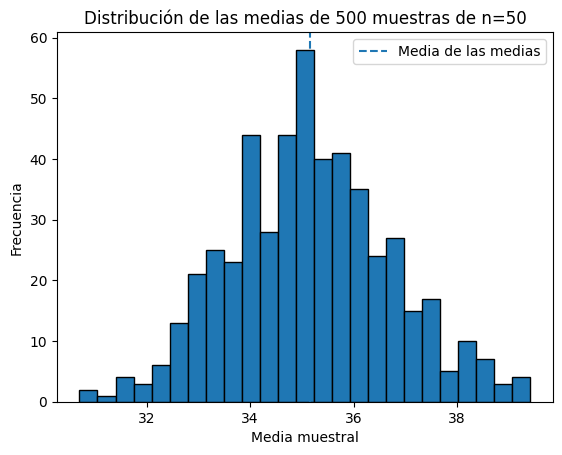

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Fijamos una semilla para poder reproducir los mismos resultados
np.random.seed(42)

#Creamos una población no normal, elegí una distribución exponencial, que la ajustaremos para que tenga media 35 y desviación estandar 12
poblacion = np.random.exponential(scale=1, size=100000)

poblacion = (poblacion - poblacion.mean()) / poblacion.std()
poblacion = poblacion * 12 + 35

#Creamos una lista vacía donde luego guardaremos las 500 medias muestrales
medias_muestrales = []

for i in range(500):
    muestra = np.random.choice(poblacion, size=50, replace=True)
    media = muestra.mean()
    medias_muestrales.append(media)

#Graficamos la distribución de las medias muestrales
plt.hist(medias_muestrales, bins=25, edgecolor='black')

plt.axvline(np.mean(medias_muestrales),
            linestyle='--',
            label='Media de las medias')

plt.xlabel('Media muestral')
plt.ylabel('Frecuencia')
plt.title('Distribución de las medias de 500 muestras de n=50')
plt.legend()

plt.show()

Explicación del código:

Como la consigna aclara que la población no debe seguir una distribución normal, pero nos pide que tenga media de 35 minutos y desviación estándar de 12 minutos, nos lleva a realizar una distribución exponencial de la misma para poder cargarle esos valores. Elegí generar 100.000 datos aleatoriamente dentro de esta distribución, entonces usé `np.random.seed(42)` para que se reproduzcan siempre los mismos al ejecutarlo.

Estandaricé los datos de la población, restando la media a cada valor y dividiendo por la desviación estándar, para obtener una distribución con media 0 y desviación estándar 1, sin modificar su forma original. Y luego los trasnformé para obtener una población con media 35 y desviación estándar 12, manteniendo la forma de la distribución original.

A continuación, creé una lista vacía (`medias_muestrales`) donde se van guardando las medias de cada muestra que se va generando (500 en total). En cada vuelta del ciclo `for` se toma una muestra de 50 usuarios de la población y se calcula la media de permanencia, que luego de guarda en la lista.

Finalmente realicé el gráfico mediante un histograma que muestra la distribución de esas 500 medias muestrales.

Análisis del gráfico:

Podemos comprobar el Teorema del Límite Central, al observar que a pesar de que la población no tiene una distribución normal, al extraer 500 muestras de tamaño n=50 > 30, la distribución de las medias muestrales presenta una forma aproximadamente normal, centrada alrededor de la media poblacional que es de 35 minutos. Observo también que, si bien existe variabilidad entre las medias muestrales, la mayoría se concentra alrededor de la media poblacional.

**c) Calcule la probabilidad de que una muestra tenga una media menor a 32
minutos y contraste el valor teórico con el obtenido en su simulación.**


In [ ]:
from scipy.stats import norm

#Datos del problema
n = 50
mu = 35  # media poblacional
sigma = 12 # desviación estandar poblacional

#Error estandar
error_estandar = round(sigma / np.sqrt(n), 4)

#Valor crítico Z
z = round((32 - mu) / error_estandar, 4)

#Probabilidad teórica acumulada
prob_teorica = round(norm.cdf(z), 4)

#Probabilidad obtenida en las 500 muestras simuladas
prob_simulada = np.mean(np.array(medias_muestrales) < 32)

#Imprimimos los resultados
print("Error estándar:", error_estandar)
print("Valor Z:", z)
print("Probabilidad teórica:", prob_teorica)
print("Probabilidad simulada:", prob_simulada)

Error estándar: 1.6971
Valor Z: -1.7677
Probabilidad teórica: 0.0386
Probabilidad simulada: 0.02


Explicación del código:

Primero cargo los datos del problema: `mu` es la media poblacional de 35 minutos, `sigma` es la desviación estándar poblacional de 12 minutos, y `n` = 50 es el tamaño de la muestra. Con estos valores calculé el error estándar con la fórmula `sigma` dividido la raíz de `n`.

Luego calculé el valor Z, para determinar cuántos errores estándar por debajo de la media poblacional se encuentra la media muestral de 32 minutos.

Mediante `norm.cdf()` calculé la probabilidad teórica de obtener una media muestral menor a 32 minutos, considerando la distribución aproximadamente normal de las medias muestrales.

Finalmente, calculé la probabilidad simulada contando qué proporción de las 500 medias generadas resultaron ser menores a 32 minutos.

Análisis de los resultados:

El error estándar obtenido fue de aproximadamente 1,7 minutos, lo que nos indica la dispersión de las medias de muestras de 50 usuarios alrededor de la media poblacional de 35 minutos.

Para una media muestral de 32 minutos, se obtuvo Z = -1,7677 ; lo que significa que 32 se encuentra a 1,7677 errores estándar por debajo de la media poblacional.

La probabilidad teórica de obtener una media menor a 32 minutos fue de 0,0386 (osea 3,86%), y la probabilidad simulada con 500 muestras fue de 0,02 (osea 2%). La diferencia no significa necesariamente que haya un error en el código. La simulación tiene variabilidad y, además, la aproximación normal no es exacta para muestras finitas.

**2) Se está desarrollando un modelo de detección de objetos para vehículos
autónomos. Se desea estimar el error promedio en la predicción de la distancia
(en cm) entre el vehículo y los obstáculos. Se busca un margen de error de 5 cm
con un nivel de confianza del 99%. Por pruebas piloto, se sabe que la desviación
estándar del error del modelo es de 10 cm. Calcula el tamaño mínimo de la
muestra de imágenes que deben ser etiquetadas manualmente para validar este
modelo.**


In [ ]:
import numpy as np
from scipy.stats import norm

#Datos del problema
nivel_confianza = 0.99
e = 5  #margen de error
sigma = 10  #desviacion estandar

#Nivel de significancia
alpha = 1 - nivel_confianza

#Valor crítico Z
z = round(norm.ppf(1 - alpha / 2), 4)

#Tamaño de la muestra
n = round((z * sigma / e) ** 2, 4)

#Redondear hacia arriba
n_minimo = int(np.ceil(n))

print("Valor crítico Z:", z)
print("Tamaño de muestra calculado:", n)
print("Tamaño mínimo de muestra:", n_minimo)

Valor crítico Z: 2.5758
Tamaño de muestra calculado: 26.539
Tamaño mínimo de muestra: 27


Explicación del código:

Primero cargué los datos del problema, luego con el valor de `nivel_confianza` puedo calcular `alpha`haciendo: 1 - `nivel_confianza`. Utilicé `norm.ppf(1 - alpha/2)` para obtener el valor crítico Z correspondiente al 99% de confianza, dividiendo `alpha` entre 2 porque trabajamos con un intervalo de confianza bilateral.

 Como la variable es cuantitativa y la población es suficientemente grande, puedo despejar el valor de `n` con la siguiente fórmula:  (z * desviación estandar / margen de error)².

Finalmente usé `np.ceil(n)` para redondear el resultado hacia arriba, ya que tiene que ser un número entero y debe garantizar el margen de error establecido


Explicación del resultado:

Se deben etiquetar manualmente al menos 27 imágenes para estimar el error promedio del modelo, con un nivel de confianza del 99%, y un margen de error de 5cm, considerando una desviación estándar estimada de 10cm.

**3) Una empresa de IA procesa un flujo constante de 5,000 inferencias por día. Se
quiere estimar el tiempo de latencia promedio de estas inferencias con un
margen de error de 0.5 milisegundos y un nivel de confianza del 99%. Se
conoce que la desviación estándar de la latencia en el servidor es de 1.2
milisegundos. Determina el tamaño de muestra mínimo necesario aplicando el
factor de corrección para población finita (N = 5,000). Si el flujo de datos
aumentara a 1,000,000 de inferencias diarias, ¿cómo afectaría esto al tamaño
de la muestra? Justifica matemáticamente por qué en Big Data el tamaño de la
población se vuelve irrelevante a partir de ciertos valores**

In [ ]:
import numpy as np
from scipy.stats import norm

#Datos del problema
nivel_confianza = 0.99
e = 0.5  #Margen de error
sigma = 1.2  #Desviación estándar poblacional

#Tamaños de población
N1 = 5000
N2 = 1000000

#Nivel de significancia
alpha = 1 - nivel_confianza

#Valor crítico Z
z = round(norm.ppf(1 - alpha / 2), 4)

#Tamaño de la muestra para cada N
n1 = (N1 * z**2 * sigma**2) / (e**2 * (N1-1) + z**2 * sigma**2)
n2 = (N2 * z**2 * sigma**2) / (e**2 * (N2-1) + z**2 * sigma**2)

#Redondeo hacia arriba
n1_minimo = int(np.ceil(n1))
n2_minimo = int(np.ceil(n2))


print("Valor crítico Z:", z)
print("Muestra para N = 5000:", n1_minimo)
print("Muestra para N = 1000000:", n2_minimo)


Valor crítico Z: 2.5758
Muestra para N = 5000: 38
Muestra para N = 1000000: 39


Explicación del código:

Primero cargué los datos del problema. Uso `N1 = 5000` para representar la cantidad inicial de inferencias diarias y `N2 = 1000000` para analizar qué pasa cuando aumenta la población.

Calculé el nivel de significancia (alpha) y luego el valor crítico Z utilizando `norm.ppf(1 - alpha/2)`, correspondiente al 99% de confianza.

Calculé el tamaño de la muestra para N1 y N2, teniendo en cuenta que debo usar la fórmula para poblaciones finitas.

Finalmente `np.ceil()` para redondear el resultado hacia arriba, ya que tiene que ser un número entero y debe garantizar el margen de error establecido

Explicación de los resultados:

Para una población de 5.000 inferencias diarias (N1), se obtuvo un tamaño mínimo de muestra de 38 inferencias. Al aumentar la población a 1.000.000 de inferencias (N2), el tamaño mínimo de muestra aumenta solamente a 39 inferencias. Es decir, que aunque la población aumenta considerablemente, el tamaño de muestra prácticamente no cambia.

Matemáticamente en el Big Data, esto se debe a que cuando la población aumenta mucho, la diferencia entre N y N-1 se vuelve insignificante. Además, el término e**2 * N2 predomina en el denominador, por lo que la fórmula se aproxima a (z**2 * sigma**2) / e**2.

De esta manera, el tamaño de la población deja de tener una influencia significativa en el cálculo. Esto explica por qué, al pasar de 5.000 a 1.000.000 de inferencias, el tamaño mínimo de muestra solo aumenta de 38 a 39.

El cálculo supone un muestreo aleatorio y la desviación estándar utilizada representa adecuadamente la variabilidad de la población.

**4) Una organización sin fines de lucro se dedica a recolectar donaciones de
alimentos no perecederos para distribuirlos a familias necesitadas. En una
campaña reciente, se recolectaron datos sobre el peso (en kilogramos) de cada
donación. Se desea estimar el peso promedio de las donaciones con un intervalo
de confianza del 95% y realizar una prueba de hipótesis para determinar si el
peso promedio es superior a 5 kilogramos.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Fijamos una semilla para obtener resultados reproducibles
np.random.seed(42)

#Generamos 30 donaciones random alrededor de 4,6 a 7 kg aprox
donaciones = np.round(np.random.uniform(4.6, 7, 30), 2)

#Convertimos a DataFrame
df_donaciones = pd.DataFrame(donaciones, columns=['peso'])

#Tamaño de la muestra
n = len(donaciones)

#Media muestral
x = round(df_donaciones['peso'].mean(), 2)

print("Cantidad de donaciones:", n)
print("Media muestral:", x)

#INTERVALO DE CONFIANZA CON BOOTSTRAP
#Definimos la cantidad de remuestreos
B = 10000

#Creo una lista para guardar las medias muestrales
medias_bootstrap = []

for i in range(B):
  muestra = df_donaciones.sample(n=n, replace=True)
  medias_bootstrap.append(muestra['peso'].mean())

#Intervalo de confianza del 95%
ic_inferior = round(np.percentile(medias_bootstrap, 2.5), 2)
ic_superior = round(np.percentile(medias_bootstrap, 97.5), 2)

print("El intervalo de confianza del 95% es:", ic_inferior, "-", ic_superior)

Cantidad de donaciones: 30
Media muestral: 5.65
El intervalo de confianza del 95% es: 5.42 - 5.89


Ecplicación del código:

Primero generé una muestra simulada de 30 donaciones con pesos aleatorios entre 4,6 y 7kg, utilizando `np.random.uniform()`. Luego convertí los datos a un DataFrame y calculé la cantidad de donaciones y su media muestral.

Para estimar el intervalo de confianza del 95%, utilicé la técnica Bootstrap. Primero definí `B=10000` para generar 10.000 muestras aleatorias del mismo tamaño que la original, seleccionando los datos con reemplazo mediante `sample(n=n, replace=True)`. Elegí `B=10000` para generar una cantidad grande de remuestreos Bootstrap para obtener una estimación mas estable del intervalo de confianza.

En cada repetición del ciclo `for` se calcula la media de la muestra y se guarda el valor en la lista vacía `medias_bootstrap`.

Finalmente, utilicé `np.percentile()` para obtener los percentiles 2,5 y 97,5 de las medias Bootstrap, que representan los límites del intervalo de confianza del 95%.

Explicación de los resultados:

A partir de una muestra simulada de 30 donaciones, se obtuvo un peso promedio de 5,65 kg.

Mediante la técnica Bootstrap, realizando 10.000 remuestreos con reemplazo, se obtuvo un intervalo de confianza del 95% comprendido entre 5,42 kg y 5,89 kg.

SEGUNDA PARTE DEL EJERCICIO

Para estimar el peso promedio de las donaciones, utilicé un intervalo de confianza bilateral del 95%, ya que quiero obtener un límite inferior y uno superior entre los cuales estimar la media poblacional.

Para la prueba de hipótesis, en cambio, utilicé un análisis unilateral de cola derecha, porque la consigna busca determinar si el peso promedio de las donaciones es superior a 5 kg


Planteo las hipótesis:

*   Hipótesis nula (H0): El peso promedio de las donaciones es menor o igual a 5kg.

    H0: µ ≤ 5
*   Hipótesis alternativa (H1): El peso promedio de las donaciones es mayor a 5kg.

    H1: µ > 5

El nivel de significancia es del 5%, α=0,05






In [ ]:
#Tamaño de la muestra
n = len(df_donaciones)

#Valor de referencia bajo H0
mu_0 = 5

#Nivel de significancia
alpha = 0.05

#Media observada de las donaciones
media_observada = df_donaciones['peso'].mean()

#Ajustamos los datos para que tengan una media de 5 kg
donaciones_h0 = df_donaciones['peso'] - media_observada + mu_0

# Generamos 10.000 remuestreos Bootstrap bajo H0
medias_h0 = []

for i in range(B):
    muestra = donaciones_h0.sample(n=n, replace=True)
    medias_h0.append(muestra.mean())

# Calculamos el p-valor unilateral derecho
p_valor = np.mean(np.array(medias_h0) >= media_observada)

print("Media observada:", round(media_observada, 2))
print("P-valor:", round(p_valor, 4))


Media observada: 5.65
P-valor: 0.0


Explicación del código:

Primero definí el tamaño de la muestra (n), el valor de referencia de 5 kg bajo la hipótesis nula (mu_0) y el nivel de significancia del 5% (alpha).

Luego calculé la media observada de las 30 donaciones utilizando `.mean()`

Para realizar la prueba de hipótesis con Bootstrap, ajusté los datos restando la media observada y sumando el valor de referencia de 5 kg. De esta manera, obtuve datos con una media de 5 kg, simulando que la hipótesis nula es verdadera, pero manteniendo la variabilidad de los datos originales.

Después generé 10.000 remuestreos Bootstrap con reemplazo, utilizando .`sample(n=n, replace=True)`, y guardé la media de cada muestra en la lista vacía `medias_h0`

Finalmente, calculé el p-valor mediante `np.mean(np.array(medias_h0) >= media_observada)`, que representa la proporción de medias simuladas bajo H₀ que son iguales o superiores a la media observada.


Explicación de los resultados:

La media muestral es de 5,65 kg, superior al valor de referencia de 5 kg establecido en la hipótesis nula.

El p-valor dá 0, lo que indica que en los 10.000 remuestreos no se observaron medias iguales o superiores a la media muestral obtenida. No significa que la probabilidad real sea exactamente cero.

Como el p-valor es menor que el nivel de significancia de 0,05 (α), se rechaza la hipótesis nula (H₀).

Existe evidencia estadística suficiente, para concluir que el peso promedio poblacional de las donaciones es superior a 5 kg.

Cabe aclarar que como generé los pesos de las donaciones artificialmente entre 4,6 y 7 kg, las conclusiones corresponden a datos simulados, no a una campaña real.

**5) “Una distribución muestral es la distribución de frecuencias de un estadístico
calculado a partir de muchas muestras tomadas de una misma población.”**
☐ Verdadero ☐ Falso


Es verdadero

**6) ¿Por qué es importante la distribución muestral para realizar inferencias
estadísticas?**

La distribución muestral es importante porque nos permite conocer cómo varía un estadístico (como la media) entre diferentes muestras de una misma población. Esto nos ayuda a estimar parámetros poblacionales, calcular márgenes de error, intervalos de confianza y realizar pruebas de hipótesis.

**7) ¿Cuál es la principal razón para utilizar el muestreo en una investigación
estadística?**

a) Asegurar respuestas rápidas.

b) Reducir el tamaño de la población.

c) Obtener resultados válidos sin necesidad de estudiar a toda la población.

d) Eliminar el error estadístico.

Respuesta:
c) Obtener resultados válidos sin necesidad de estudiar a toda la población.

El muestreo nos permite estudiar una parte representativa de una población, y a partir de sus resultados, realizar inferencias sobre la población completa.

**8) Se ha implementado un nuevo algoritmo de recomendación en una plataforma
de streaming. El algoritmo actual tiene un tiempo de permanencia promedio de
45 minutos por usuario. Se sospecha que el nuevo modelo aumenta ese tiempo.**

a) Define la Hipótesis Nula (H0) y la Hipótesis Alternativa (H1) para este caso.

Respuesta:

Hipótesis nula(H0):  H0: µ <= 45

El nuevo algoritmo de recomendación no aumenta el tiempo promedio de permanencia de los usuarios, es decir, se mantiene en 45 minutos o menos.

Hipótesis alternativa(H1):  H1: µ > 45

El nuevo algoritmo de recomendación aumenta el tiempo promedio de permanencia de los usuarios por encima de los 45 minutos.

**b) Explica qué significa cometer un Error de Tipo I (falso positivo) en este
contexto técnico: ¿Qué decisión tomaría la empresa y qué impacto tendría?**

Respuesta:

Un Error de Tipo I ocurre cuando rechazamos la hipótesis nula (H₀) siendo esta verdadera.
En este caso, significa que la empresa concluye que el nuevo algoritmo aumenta el tiempo promedio de permanencia de los usuarios, cuando en realidad no lo hace.

La empresa implementaría el nuevo algoritmo creyendo que mejora el rendimiento de la plataforma.

El impacto que tendría es que la empresa podría invertir tiempo y recursos en implementar un algoritmo que no ofrece una mejora real, generando costos innecesarios y tomando decisiones basadas en una conclusión incorrecta.

**c) Si tras realizar la prueba obtienes un p-valor de 0.03, ¿rechazarías la
hipótesis nula con un nivel de significancia del 5%? Justifica tu respuesta desde
la perspectiva de la toma de decisiones basada en datos.**

Respuesta:

Nivel de significancia: α = 5% = 0,05
p-valor: p = 0,03

Como p < α, se rechaza la hipótesis nula (H0).

Esto significa que existe evidencia estadísticamente significativa para considerar que el nuevo algoritmo aumenta el tiempo promedio de permanencia de los usuarios por encima de los 45 minutos.

Desde la perspectiva de la toma de decisiones basada en datos, la empresa cuenta con evidencia para considerar la implementación del nuevo algoritmo. Sin embargo, también debería evaluar la magnitud de la mejora y los costos de implementación, ya que un resultado estadísticamente significativo no garantiza que la mejora sea importante a nivel práctico.